In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from wordcloud import WordCloud
import os

BASE = '/content/drive/MyDrive/edtech_absa'

df_scores  = pd.read_csv(f'{BASE}/data/processed/platform_scores.csv')
df_sents   = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')

print("Scores loaded:", df_scores.shape)
print("Sentences loaded:", df_sents.shape)
print("\nPlatforms:", df_scores['platform'].unique())
print("Aspects:",   df_scores['aspect'].unique())

Mounted at /content/drive
Scores loaded: (35, 4)
Sentences loaded: (35409, 18)

Platforms: ['Coursera' 'LinkedIn_Learning' 'Pluralsight' 'Udemy' 'edX']
Aspects: ['Certification' 'Community' 'Content_Quality' 'Instructor' 'Platform_UX'
 'Pricing' 'Support']


In [2]:
# CELL 1 — Always run this first in NB04
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import os

BASE = '/content/drive/MyDrive/edtech_absa'

df_scores = pd.read_csv(f'{BASE}/data/processed/platform_scores.csv')
df_sents  = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')

print("Scores shape:", df_scores.shape)
print("Sentences shape:", df_sents.shape)
print("\nPlatforms:", df_scores['platform'].unique())
print("Aspects:", df_scores['aspect'].unique())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scores shape: (35, 4)
Sentences shape: (35409, 18)

Platforms: ['Coursera' 'LinkedIn_Learning' 'Pluralsight' 'Udemy' 'edX']
Aspects: ['Certification' 'Community' 'Content_Quality' 'Instructor' 'Platform_UX'
 'Pricing' 'Support']


In [3]:
# CELL 2 — Radar Chart

import plotly.graph_objects as go

# Fix kaleido version conflict
import subprocess
subprocess.run(['pip', 'install', 'kaleido==0.2.1'],
               capture_output=True)  # specific version that works in Colab

aspects = [
    'Content_Quality', 'Instructor', 'Platform_UX',
    'Pricing', 'Support', 'Certification', 'Community'
]

COLORS = {
    'Coursera':          '#0056D2',
    'Udemy':             '#A435F0',
    'edX':               '#02262B',
    'LinkedIn_Learning': '#0A66C2',
    'Pluralsight':       '#F15B2A',
}

fig = go.Figure()

for platform in df_scores['platform'].unique():
    pdf = df_scores[df_scores['platform'] == platform]

    scores = []
    for aspect in aspects:
        row = pdf[pdf['aspect'] == aspect]
        scores.append(float(row['score'].values[0]) if len(row) > 0 else 0)

    scores_closed  = scores + [scores[0]]
    aspects_closed = aspects + [aspects[0]]

    fig.add_trace(go.Scatterpolar(
        r=scores_closed,
        theta=aspects_closed,
        fill='toself',
        fillcolor=COLORS.get(platform, '#888888'),
        line=dict(color=COLORS.get(platform, '#888888'), width=2.5),
        opacity=0.35,
        name=platform
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 10],
            tickvals=[2, 4, 6, 8, 10],
            tickfont=dict(size=10),
            gridcolor='lightgrey'
        ),
        angularaxis=dict(tickfont=dict(size=12))
    ),
    title=dict(
        text='EdTech Competitive Intelligence Radar<br>'
             '<sup>Aspect-Based Sentiment Analysis · 12,500 reviews · 5 platforms · 5 regions</sup>',
        x=0.5,
        font=dict(size=16)
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.25,
        xanchor='center',
        x=0.5
    ),
    width=750, height=650,
    paper_bgcolor='white',
)

# Save HTML first — always works
fig.write_html(f'{BASE}/outputs/radar_chart.html')
print("HTML saved!")

# Save PNG — use matplotlib as backup if kaleido fails
try:
    import plotly.io as pio
    pio.kaleido.scope.default_format = "png"
    fig.write_image(f'{BASE}/outputs/radar_chart.png', scale=2)
    print("PNG saved!")
except Exception as e:
    print(f"Kaleido PNG failed — using matplotlib backup...")
    # Matplotlib backup: simple static version
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    num_aspects = len(aspects)
    angles = np.linspace(0, 2 * np.pi, num_aspects, endpoint=False).tolist()
    angles += angles[:1]

    fig_mpl, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for platform in df_scores['platform'].unique():
        pdf = df_scores[df_scores['platform'] == platform]
        scores = []
        for aspect in aspects:
            row = pdf[pdf['aspect'] == aspect]
            scores.append(float(row['score'].values[0]) if len(row) > 0 else 0)
        scores += scores[:1]

        color = COLORS.get(platform, '#888888')
        ax.plot(angles, scores, 'o-', linewidth=2, color=color, label=platform)
        ax.fill(angles, scores, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([a.replace('_', '\n') for a in aspects], size=10)
    ax.set_ylim(0, 10)
    ax.set_yticks([2, 4, 6, 8, 10])
    ax.set_title('EdTech Competitive Intelligence Radar\n'
                 'Aspect-Based Sentiment · 12,500 reviews · 5 platforms',
                 size=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{BASE}/outputs/radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("PNG saved via matplotlib backup!")

fig.show()
print("\nRadar chart complete!")

HTML saved!
PNG saved!



Radar chart complete!


In [4]:
# Must-Win Score = Importance × Gap from leader
# Importance = how many reviews mention this aspect (normalized)
# Gap = leader's score minus platform's score

aspect_importance = (
    df_sents.groupby('aspect')
    .size()
    .reset_index(name='mention_count')
)
aspect_importance['importance'] = (
    aspect_importance['mention_count'] /
    aspect_importance['mention_count'].max()
)

# Get leader score per aspect
leader_scores = (
    df_scores.groupby('aspect')['score']
    .max()
    .reset_index(name='leader_score')
)

must_win_rows = []

for platform in df_scores['platform'].unique():
    pdf = df_scores[df_scores['platform'] == platform]

    for _, asp_row in aspect_importance.iterrows():
        aspect = asp_row['aspect']
        importance = asp_row['importance']

        platform_score = pdf[pdf['aspect'] == aspect]['score']
        platform_score = float(platform_score.values[0]) if len(platform_score) > 0 else 0

        leader_score = float(
            leader_scores[leader_scores['aspect'] == aspect]['leader_score'].values[0]
        )

        gap = max(0, leader_score - platform_score)
        must_win_score = round(importance * gap, 3)

        must_win_rows.append({
            'platform':       platform,
            'aspect':         aspect,
            'platform_score': platform_score,
            'leader_score':   leader_score,
            'importance':     round(importance, 3),
            'gap':            round(gap, 3),
            'must_win_score': must_win_score
        })

df_must_win = pd.DataFrame(must_win_rows)
df_must_win = df_must_win.sort_values(
    ['platform', 'must_win_score'], ascending=[True, False]
)

print("TOP MUST-WIN CATEGORIES PER PLATFORM")
print("=" * 55)
for platform in df_must_win['platform'].unique():
    print(f"\n{platform}:")
    top3 = df_must_win[df_must_win['platform'] == platform].head(3)
    for _, row in top3.iterrows():
        print(f"  {row['aspect']:<20} score={row['platform_score']} "
              f"gap={row['gap']} must_win={row['must_win_score']}")

df_must_win.to_csv(f'{BASE}/data/processed/must_win_scores.csv', index=False)
print("\nSaved must_win_scores.csv!")

TOP MUST-WIN CATEGORIES PER PLATFORM

Coursera:
  Platform_UX          score=3.82 gap=1.0 must_win=1.0
  Pricing              score=3.0 gap=2.73 must_win=0.629
  Support              score=4.14 gap=2.14 must_win=0.591

LinkedIn_Learning:
  Platform_UX          score=2.8 gap=2.02 must_win=2.02
  Support              score=3.19 gap=3.09 must_win=0.853
  Pricing              score=2.65 gap=3.08 must_win=0.71

Pluralsight:
  Platform_UX          score=3.56 gap=1.26 must_win=1.26
  Pricing              score=4.41 gap=1.32 must_win=0.304
  Instructor           score=5.3 gap=1.44 must_win=0.159

Udemy:
  Platform_UX          score=3.34 gap=1.48 must_win=1.48
  Support              score=3.69 gap=2.59 must_win=0.715
  Pricing              score=3.94 gap=1.79 must_win=0.412

edX:
  Support              score=6.02 gap=0.26 must_win=0.072
  Certification        score=5.8 gap=0.31 must_win=0.025
  Content_Quality      score=5.12 gap=0.05 must_win=0.013

Saved must_win_scores.csv!


Top Must-Win per platform:
            platform       aspect  platform_score  leader_score  \
0           Coursera  Platform_UX            3.82          4.82   
1  LinkedIn_Learning  Platform_UX            2.80          4.82   
2        Pluralsight  Platform_UX            3.56          4.82   
3              Udemy  Platform_UX            3.34          4.82   
4                edX      Support            6.02          6.28   

   must_win_score  
0           1.000  
1           2.020  
2           1.260  
3           1.480  
4           0.072  


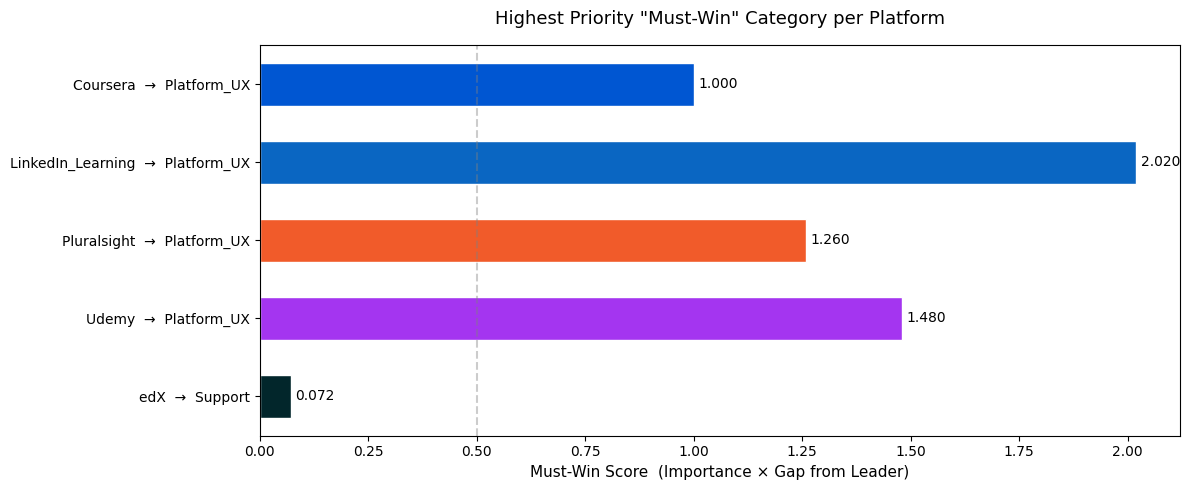

Must-Win chart saved!


In [ ]:
# CELL 4 — Must-Win bar chart

COLORS = {
    'Coursera':          '#0056D2',
    'Udemy':             '#A435F0',
    'edX':               '#02262B',
    'LinkedIn_Learning': '#0A66C2',
    'Pluralsight':       '#F15B2A',
}

# Fix: reset_index to make sure platform is a column not index
df_must_win_clean = df_must_win.reset_index(drop=True)

# Get the single highest must-win aspect per platform
top_must_win = (
    df_must_win_clean
    .sort_values('must_win_score', ascending=False)
    .groupby('platform')
    .first()
    .reset_index()
)

print("Top Must-Win per platform:")
print(top_must_win[['platform', 'aspect', 'platform_score',
                     'leader_score', 'must_win_score']])

fig2, ax = plt.subplots(figsize=(12, 5))

labels = top_must_win['platform'] + '  →  ' + top_must_win['aspect']

bars = ax.barh(
    labels,
    top_must_win['must_win_score'],
    color=[COLORS.get(p, '#888') for p in top_must_win['platform']],
    edgecolor='white',
    height=0.55
)

ax.set_xlabel('Must-Win Score  (Importance × Gap from Leader)', fontsize=11)
ax.set_title('Highest Priority "Must-Win" Category per Platform',
             fontsize=13, pad=15)
ax.axvline(x=0.5, color='grey', linestyle='--', alpha=0.4)

for bar, val in zip(bars, top_must_win['must_win_score']):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/must_win_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Must-Win chart saved!")

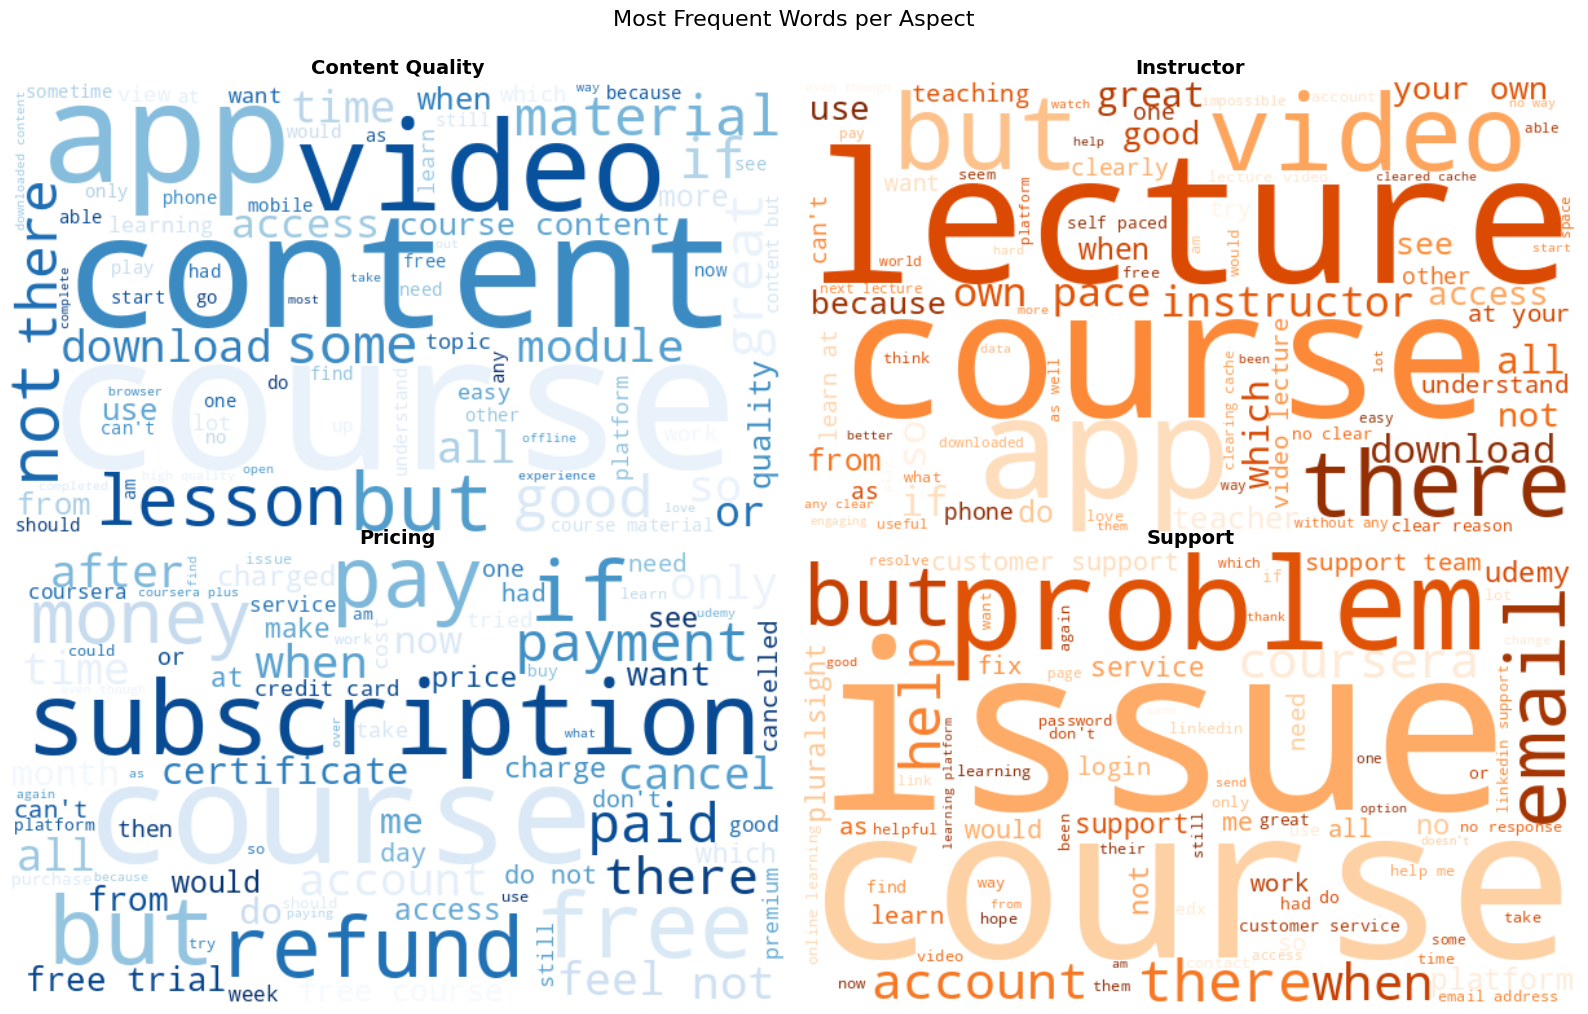

Word clouds saved!


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

aspects_to_plot = ['Content_Quality', 'Instructor', 'Pricing', 'Support']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, aspect in enumerate(aspects_to_plot):
    # Get all sentences for this aspect
    text = ' '.join(
        df_sents[df_sents['aspect'] == aspect]['sentence']
        .fillna('').tolist()
    )

    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap='Blues' if i % 2 == 0 else 'Oranges',
        max_words=80,
        stopwords={
            'the','a','an','is','it','this','that','was','are',
            'be','to','of','and','in','for','on','with','have',
            'has','will','can','i','my','we','they','our','you',
            'get','got','just','like','also','very','really'
        }
    ).generate(text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{aspect.replace("_"," ")}', fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Most Frequent Words per Aspect', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word clouds saved!")

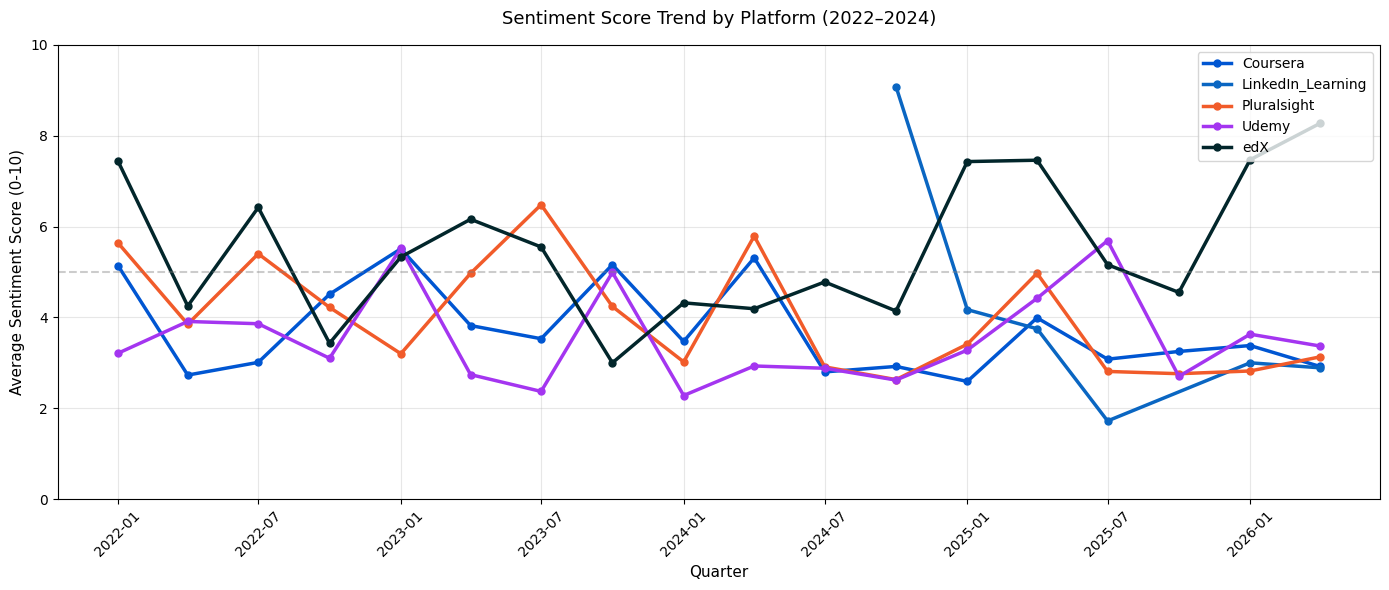

Trend chart saved!


In [ ]:
# CELL 6 — Temporal trend analysis

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])
df['quarter'] = df['date'].dt.to_period('Q')
df_trend = df[df['date'].dt.year >= 2022].copy()

trend = (
    df_trend.groupby(['platform', 'quarter'])['sentiment_score']
    .mean()
    .reset_index()
)
trend['quarter_dt'] = trend['quarter'].dt.to_timestamp()
trend['sentiment_score'] = trend['sentiment_score'].round(2)

COLORS = {
    'Coursera': '#0056D2',
    'Udemy': '#A435F0',
    'edX': '#02262B',
    'LinkedIn_Learning': '#0A66C2',
    'Pluralsight': '#F15B2A',
}

fig, ax = plt.subplots(figsize=(14, 6))

for platform in trend['platform'].unique():
    pdf = trend[trend['platform'] == platform].sort_values('quarter_dt')
    ax.plot(
        pdf['quarter_dt'],
        pdf['sentiment_score'],
        marker='o',
        linewidth=2.5,
        markersize=5,
        label=platform,
        color=COLORS.get(platform, '#888')
    )

ax.set_title('Sentiment Score Trend by Platform (2022–2024)', fontsize=13, pad=15)
ax.set_ylabel('Average Sentiment Score (0-10)', fontsize=11)
ax.set_xlabel('Quarter', fontsize=11)
ax.axhline(y=5.0, color='grey', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/trend_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Trend chart saved!")

In [ ]:
# CELL 6 — Temporal trend analysis

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])
df['quarter'] = df['date'].dt.to_period('Q')
df_trend = df[df['date'].dt.year >= 2022].copy()

trend = (
    df_trend.groupby(['platform', 'quarter'])['sentiment_score']
    .mean()
    .reset_index()
)
trend['quarter_dt'] = trend['quarter'].dt.to_timestamp()
trend['sentiment_score'] = trend['sentiment_score'].round(2)

COLORS = {
    'Coursera': '#0056D2',
    'Udemy': '#A435F0',
    'edX': '#02262B',
    'LinkedIn_Learning': '#0A66C2',
    'Pluralsight': '#F15B2A',
}

fig, ax = plt.subplots(figsize=(14, 6))

for platform in trend['platform'].unique():
    pdf = trend[trend['platform'] == platform].sort_values('quarter_dt')
    ax.plot(
        pdf['quarter_dt'],
        pdf['sentiment_score'],
        marker='o',
        linewidth=2.5,
        markersize=5,
        label=platform,
        color=COLORS.get(platform, '#888')
    )

ax.set_title('Sentiment Score Trend by Platform (2022–2024)', fontsize=13, pad=15)
ax.set_ylabel('Average Sentiment Score (0-10)', fontsize=11)
ax.set_xlabel('Quarter', fontsize=11)
ax.axhline(y=5.0, color='grey', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/trend_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Trend chart saved!")

NameError: name 'BASE' is not defined

In [ ]:
# CELL 1 — Always run this first in NB04
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import os

BASE = '/content/drive/MyDrive/edtech_absa'

df_scores = pd.read_csv(f'{BASE}/data/processed/platform_scores.csv')
df_sents  = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')

print("Scores shape:", df_scores.shape)
print("Sentences shape:", df_sents.shape)
print("\nPlatforms:", df_scores['platform'].unique())
print("Aspects:", df_scores['aspect'].unique())

Mounted at /content/drive
Scores shape: (35, 4)
Sentences shape: (35409, 18)

Platforms: ['Coursera' 'LinkedIn_Learning' 'Pluralsight' 'Udemy' 'edX']
Aspects: ['Certification' 'Community' 'Content_Quality' 'Instructor' 'Platform_UX'
 'Pricing' 'Support']


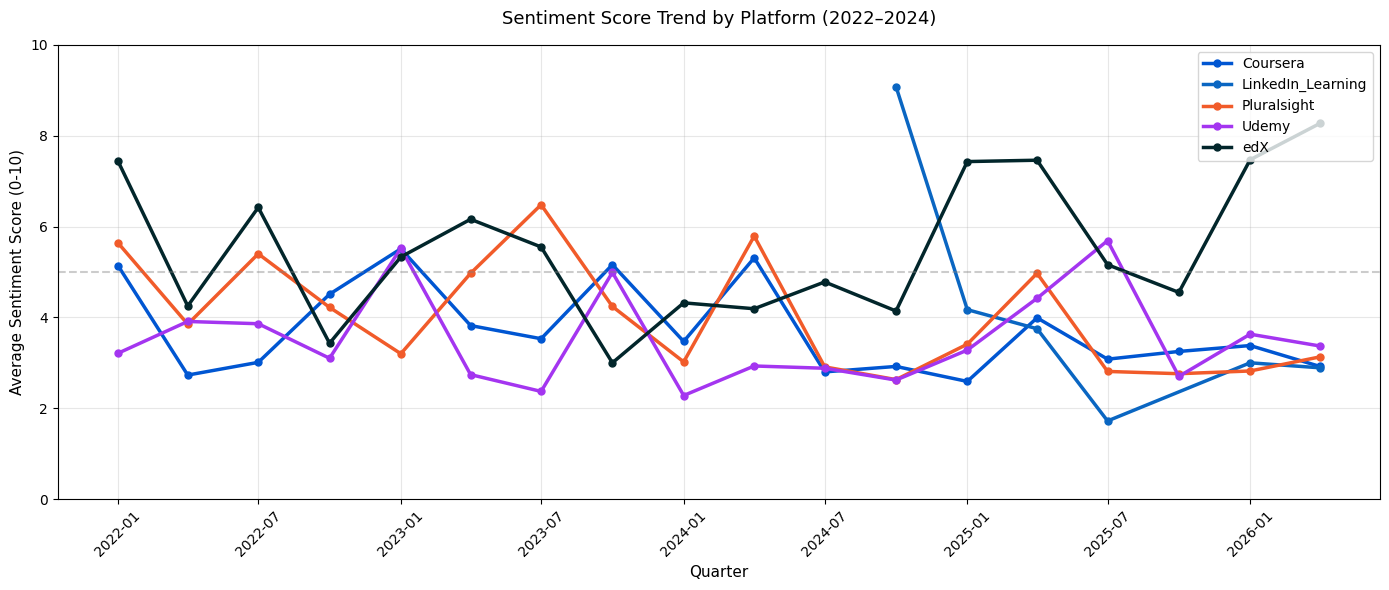

Trend chart saved!


In [ ]:
# CELL 6 — Temporal trend analysis

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(f'{BASE}/data/processed/aspect_sentiments.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])
df['quarter'] = df['date'].dt.to_period('Q')
df_trend = df[df['date'].dt.year >= 2022].copy()

trend = (
    df_trend.groupby(['platform', 'quarter'])['sentiment_score']
    .mean()
    .reset_index()
)
trend['quarter_dt'] = trend['quarter'].dt.to_timestamp()
trend['sentiment_score'] = trend['sentiment_score'].round(2)

COLORS = {
    'Coursera': '#0056D2',
    'Udemy': '#A435F0',
    'edX': '#02262B',
    'LinkedIn_Learning': '#0A66C2',
    'Pluralsight': '#F15B2A',
}

fig, ax = plt.subplots(figsize=(14, 6))

for platform in trend['platform'].unique():
    pdf = trend[trend['platform'] == platform].sort_values('quarter_dt')
    ax.plot(
        pdf['quarter_dt'],
        pdf['sentiment_score'],
        marker='o',
        linewidth=2.5,
        markersize=5,
        label=platform,
        color=COLORS.get(platform, '#888')
    )

ax.set_title('Sentiment Score Trend by Platform (2022–2024)', fontsize=13, pad=15)
ax.set_ylabel('Average Sentiment Score (0-10)', fontsize=11)
ax.set_xlabel('Quarter', fontsize=11)
ax.axhline(y=5.0, color='grey', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/trend_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Trend chart saved!")